Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
import warnings
warnings.filterwarnings("ignore")

plt.style.use('seaborn-v0_8-darkgrid')

print("Loading aligned macro and sentiment data...")
# Load the processed data from the ETL pipeline
df = pd.read_csv('../data/processed/macro_sentiment_aligned.csv', parse_dates=['observation_date'], index_col='observation_date')

y_inflation = df['Inflation_MoM']
x_sentiment = df['News Sentiment']

print("Data loaded successfully. Total months ready for modeling:", len(df))

Loading aligned macro and sentiment data...
Data loaded successfully. Total months ready for modeling: 555


HMM

In [2]:
print("\n--- Training Static HMMs ---")

# 2A: Baseline HMM (Inflation Only)
print("Training Baseline HMM...")
mod_hmm_base = sm.tsa.MarkovRegression(
    endog=y_inflation, 
    k_regimes=2, 
    switching_variance=True
)
res_hmm_base = mod_hmm_base.fit()

# 2B: HMM + Semantic Index
print("Training HMM + Semantic Index...")
mod_hmm_sem = sm.tsa.MarkovRegression(
    endog=y_inflation, 
    k_regimes=2, 
    exog=x_sentiment, 
    switching_variance=True
)
res_hmm_sem = mod_hmm_sem.fit()

print("Static HMM training complete.")


--- Training Static HMMs ---
Training Baseline HMM...
Training HMM + Semantic Index...
Static HMM training complete.


HMM Evaluation & Visualization


--- Comparing Static HMMs (Baseline vs. Semantic) ---
                    Model        AIC        BIC
           HMM (Baseline) -36.074510 -10.160702
HMM (with Semantic Index) -32.175466   2.376279


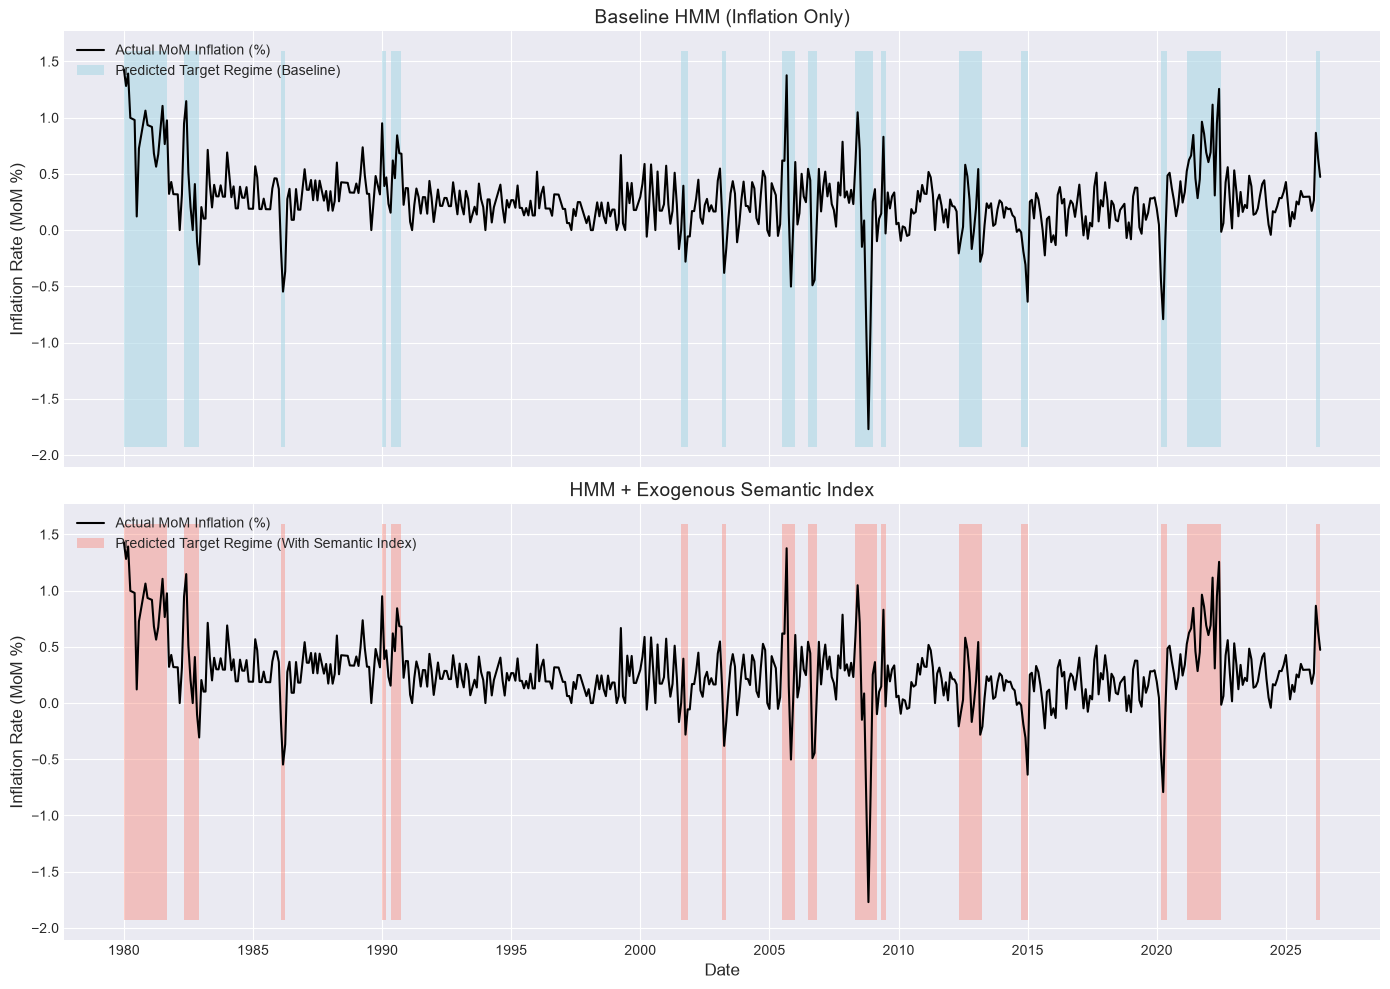

In [3]:
print("\n--- Comparing Static HMMs (Baseline vs. Semantic) ---")

# 1. Quantitative Comparison (AIC/BIC)
hmm_comparison = pd.DataFrame({
    'Model': ['HMM (Baseline)', 'HMM (with Semantic Index)'],
    'AIC': [res_hmm_base.aic, res_hmm_sem.aic],
    'BIC': [res_hmm_base.bic, res_hmm_sem.bic]
})
print(hmm_comparison.to_string(index=False))

# 2. Visual Comparison (Stacked Subplots)
fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

# Extract probabilities for the high-volatility regime (Regime 1) from both models
prob_base = res_hmm_base.smoothed_marginal_probabilities[1]
prob_sem = res_hmm_sem.smoothed_marginal_probabilities[1]

# Top Plot: Baseline HMM
axes[0].plot(df.index, y_inflation, color='black', label='Actual MoM Inflation (%)', linewidth=1.5)
axes[0].fill_between(df.index, axes[0].get_ylim()[0], axes[0].get_ylim()[1], 
                where=(prob_base > 0.5), 
                facecolor='lightblue', alpha=0.6, label='Predicted Target Regime (Baseline)')
axes[0].set_title('Baseline HMM (Inflation Only)', fontsize=14)
axes[0].set_ylabel('Inflation Rate (MoM %)', fontsize=12)
axes[0].legend(loc='upper left')

# Bottom Plot: HMM + Semantic Index
axes[1].plot(df.index, y_inflation, color='black', label='Actual MoM Inflation (%)', linewidth=1.5)
axes[1].fill_between(df.index, axes[1].get_ylim()[0], axes[1].get_ylim()[1], 
                where=(prob_sem > 0.5), 
                facecolor='salmon', alpha=0.4, label='Predicted Target Regime (With Semantic Index)')
axes[1].set_title('HMM + Exogenous Semantic Index', fontsize=14)
axes[1].set_ylabel('Inflation Rate (MoM %)', fontsize=12)
axes[1].set_xlabel('Date', fontsize=12)
axes[1].legend(loc='upper left')

plt.tight_layout()
plt.show()